# Model Training - FLAML AutoML

This notebook trains a pitcher-batter matchup prediction model using FLAML AutoML.

**Features:**
- Automated hyperparameter tuning with FLAML
- Uses null-tolerant tree models (LightGBM, XGBoost, CatBoost)
- Comprehensive evaluation metrics
- Feature importance analysis
- SHAP explanations for individual predictions

**Outcome Classes:** 1B, 2B, 3B, BB, HR, K, OUT (alphabetical order from LabelEncoder)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pathlib import Path
from src.model.train_flaml import (
    MatchupModelTrainer,
    load_processed_data,
    prepare_features,
)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Initialize SHAP JS visualization
shap.initjs()

/Applications/miniconda3/envs/mlbenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Prepare Data

In [2]:
# Load processed data
train_df, val_df, test_df = load_processed_data('../data/processed')

Loaded data:
  Train: 853,340 rows, 2021-04-01 00:00:00 to 2025-05-31 00:00:00
  Val:   42,831 rows, 2025-06-01 00:00:00 to 2025-07-13 00:00:00
  Test:  90,898 rows, 2025-07-18 00:00:00 to 2026-03-30 00:00:00


In [3]:
# Prepare features (returns X, y, feature_names, outcome_classes)
X_train, y_train, feature_names, outcome_classes = prepare_features(train_df, '../models/matchup_preprocessor.pkl')
X_val, y_val, _, _ = prepare_features(val_df, '../models/matchup_preprocessor.pkl')
X_test, y_test, _, _ = prepare_features(test_df, '../models/matchup_preprocessor.pkl')

print(f"Outcome classes (from preprocessor): {outcome_classes}")
print(f"\nFeature count: {len(feature_names)}")
print(f"\nTrain shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Outcome classes (from preprocessor): [np.str_('1B'), np.str_('2B'), np.str_('3B'), np.str_('BB'), np.str_('HR'), np.str_('K'), np.str_('OUT')]

Feature count: 207

Train shape: (853340, 207)
Val shape: (42831, 207)
Test shape: (90898, 207)


In [4]:
# Check null distribution
null_counts = X_train.isnull().sum().sort_values(ascending=False)
print(f"Total null values: {null_counts.sum():,}")
print(f"\nTop 15 columns with nulls:")
print(null_counts.head(15))

Total null values: 30,173,976

Top 15 columns with nulls:
p_kn_whiff_pct         851870
p_kn_hmov_avg          851870
p_kn_vmov_avg          851870
p_kn_spin_avg          851870
p_kn_velo_avg          851870
b_vs_kn_xwoba          851498
b_vs_kn_whiff_pct      845883
b_vs_kn_contact_pct    845883
p_sv_hmov_avg          828151
p_sv_whiff_pct         828151
p_sv_vmov_avg          828151
p_sv_spin_avg          828151
p_sv_velo_avg          828151
p_kc_vmov_avg          744712
p_kc_hmov_avg          744712
dtype: int64


In [5]:
# Class distribution
print("Outcome distribution in training set:")
outcome_counts = pd.Series(y_train).value_counts().sort_index()
for idx, count in outcome_counts.items():
    pct = count / len(y_train) * 100
    print(f"  {outcome_classes[idx]:4s}: {count:,} ({pct:.1f}%)")

Outcome distribution in training set:
  1B  : 122,251 (14.3%)
  2B  : 37,773 (4.4%)
  3B  : 3,245 (0.4%)
  BB  : 70,892 (8.3%)
  HR  : 26,533 (3.1%)
  K   : 197,325 (23.1%)
  OUT : 395,321 (46.3%)


## 2. Train Model with FLAML AutoML

FLAML will automatically:
- Try different tree-based algorithms (LightGBM, XGBoost, CatBoost)
- Tune hyperparameters within the time budget
- Select the best model based on validation performance

In [6]:
# Training configuration
TIME_BUDGET = 3600*2 # 3 minutes - increase for better model
METRIC = "log_loss"  # Optimize for probability calibration
MIN_NUM_LEAVES = 128  # Higher = more complex model, better for extreme values

print(f"Training with time budget: {TIME_BUDGET}s ({TIME_BUDGET/60:.0f} minutes)")
print(f"Optimization metric: {METRIC}")
print(f"Min num_leaves: {MIN_NUM_LEAVES} (higher avoids regression-to-mean)")
print(f"Estimators: LightGBM, XGBoost, CatBoost (all handle nulls natively)")

Training with time budget: 7200s (120 minutes)
Optimization metric: log_loss
Min num_leaves: 128 (higher avoids regression-to-mean)
Estimators: LightGBM, XGBoost, CatBoost (all handle nulls natively)


In [7]:
# Initialize trainer
trainer = MatchupModelTrainer(
    time_budget=TIME_BUDGET,
    metric=METRIC,
    seed=42,
    min_num_leaves=MIN_NUM_LEAVES,  # Avoid regression-to-mean
)

# Train model
trainer.fit(
    X_train, y_train,
    X_val, y_val,
    feature_names=feature_names,
    verbose=1,
)

# Set outcome classes from preprocessor
trainer.outcome_classes = outcome_classes

Training with FLAML AutoML
  Time budget: 7200s
  Metric: log_loss
  Estimators: ['lgbm', 'xgboost', 'catboost']
  Train shape: (853340, 207)
  Val shape: (42831, 207)
  Null values in train: 30,173,976
  Min num_leaves: 128

Best model: catboost
Best log_loss: 1.4108


In [ ]:
# Best model info
print(f"\n{'='*60}")
print(f"Best Model: {trainer.automl.best_estimator}")
print(f"Best {METRIC}: {trainer.automl.best_loss:.4f}")
# print(f"Time to best model: {trainer.automl.time_to_best:.1f}s")
print(f"{'='*60}")

print("\nBest hyperparameters:")
for param, value in trainer.automl.best_config.items():
    print(f"  {param}: {value}")

## 3. Model Evaluation

Comprehensive metrics across train, validation, and test sets.

In [9]:
# Evaluate on all sets
train_metrics = trainer.evaluate(X_train, y_train, 'train')
val_metrics = trainer.evaluate(X_val, y_val, 'val')
test_metrics = trainer.evaluate(X_test, y_test, 'test')

trainer.print_evaluation(train_metrics)
trainer.print_evaluation(val_metrics)
trainer.print_evaluation(test_metrics)


Evaluation: train (853,340 samples)
Accuracy:           0.4664
Balanced Accuracy:  0.1486
Log Loss:           1.4188
F1 (macro):         0.1067
F1 (weighted):      0.3195
ROC AUC (OvR):      0.5869

Per-class F1 scores:
  1B  : 0.0000 (n=122,251.0)
  2B  : 0.0000 (n=37,773.0)
  3B  : 0.0000 (n=3,245.0)
  BB  : 0.0000 (n=70,892.0)
  HR  : 0.0000 (n=26,533.0)
  K   : 0.1145 (n=197,325.0)
  OUT : 0.6326 (n=395,321.0)

Evaluation: val (42,831 samples)
Accuracy:           0.4767
Balanced Accuracy:  0.1474
Log Loss:           1.4108
F1 (macro):         0.1049
F1 (weighted):      0.3256
ROC AUC (OvR):      0.5774

Per-class F1 scores:
  1B  : 0.0000 (n=6,227.0)
  2B  : 0.0000 (n=1,832.0)
  3B  : 0.0000 (n=147.0)
  BB  : 0.0000 (n=3,398.0)
  HR  : 0.0000 (n=1,373.0)
  K   : 0.0913 (n=9,529.0)
  OUT : 0.6433 (n=20,325.0)

Evaluation: test (90,898 samples)
Accuracy:           0.4642
Balanced Accuracy:  0.1476
Log Loss:           1.4243
F1 (macro):         0.1046
F1 (weighted):      0.3153
ROC A

In [10]:
# Summary comparison table
summary = pd.DataFrame({
    'Train': [
        train_metrics['accuracy'],
        train_metrics['balanced_accuracy'],
        train_metrics['log_loss'],
        train_metrics['f1_macro'],
        train_metrics['roc_auc_ovr'],
    ],
    'Validation': [
        val_metrics['accuracy'],
        val_metrics['balanced_accuracy'],
        val_metrics['log_loss'],
        val_metrics['f1_macro'],
        val_metrics['roc_auc_ovr'],
    ],
    'Test': [
        test_metrics['accuracy'],
        test_metrics['balanced_accuracy'],
        test_metrics['log_loss'],
        test_metrics['f1_macro'],
        test_metrics['roc_auc_ovr'],
    ],
}, index=['Accuracy', 'Balanced Accuracy', 'Log Loss', 'F1 (macro)', 'ROC AUC (OvR)'])

print("\nMetrics Summary:")
print(summary.round(4).to_string())


Metrics Summary:
                    Train  Validation    Test
Accuracy           0.4664      0.4767  0.4642
Balanced Accuracy  0.1486      0.1474  0.1476
Log Loss           1.4188      1.4108  1.4243
F1 (macro)         0.1067      0.1049  0.1046
ROC AUC (OvR)      0.5869      0.5774  0.5801


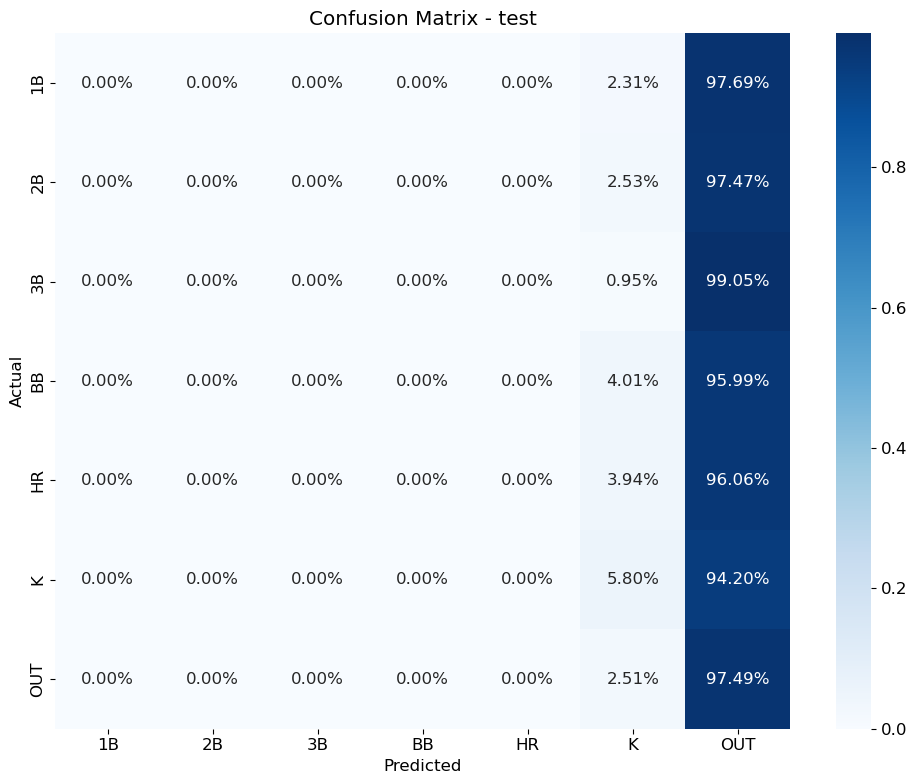

In [11]:
# Confusion matrix - Test set
fig = trainer.plot_confusion_matrix(
    test_metrics,
    normalize=True,
    figsize=(10, 8),
)
plt.show()

In [12]:
# Per-class metrics (test set)
per_class = pd.DataFrame(test_metrics['classification_report']).T
per_class = per_class.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
per_class = per_class.round(4)
print("\nPer-class metrics (Test set):")
display(per_class)


Per-class metrics (Test set):


,precision,recall,f1-score,support
1B,0.0000,0.0000,0.0000,12927.0
2B,0.0000,0.0000,0.0000,3950.0
3B,0.0000,0.0000,0.0000,317.0
BB,0.0000,0.0000,0.0000,7640.0
HR,0.0000,0.0000,0.0000,2971.0
K,0.3941,0.0580,0.1011,21067.0
OUT,0.4667,0.9749,0.6312,42026.0


## 4. Feature Importance Analysis

Understand which features drive model predictions.

In [13]:
# Get feature importance
importance_df = trainer.get_feature_importance()

print(f"\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))


Top 20 Most Important Features:
              feature  importance  importance_pct  cumulative_pct
   b_avg_launch_angle    5.443069        5.443069        5.443069
          b_chase_pct    3.998440        3.998440        9.441510
       p_f_strike_pct    3.764254        3.764254       13.205764
        p_contact_pct    3.691612        3.691612       16.897376
          p_whiff_pct    2.976549        2.976549       19.873924
          matchup_RvR    2.915426        2.915426       22.789350
            p_csw_pct    2.718833        2.718833       25.508183
            b_csw_pct    2.448355        2.448355       27.956538
  p_chase_pct_induced    2.350384        2.350384       30.306922
          b_swing_pct    2.163041        2.163041       32.469964
      p_total_pitches    1.941741        1.941741       34.411705
          b_whiff_pct    1.716551        1.716551       36.128256
   b_vs_RHP_whiff_pct    1.662757        1.662757       37.791012
        b_contact_pct    1.660254        1.

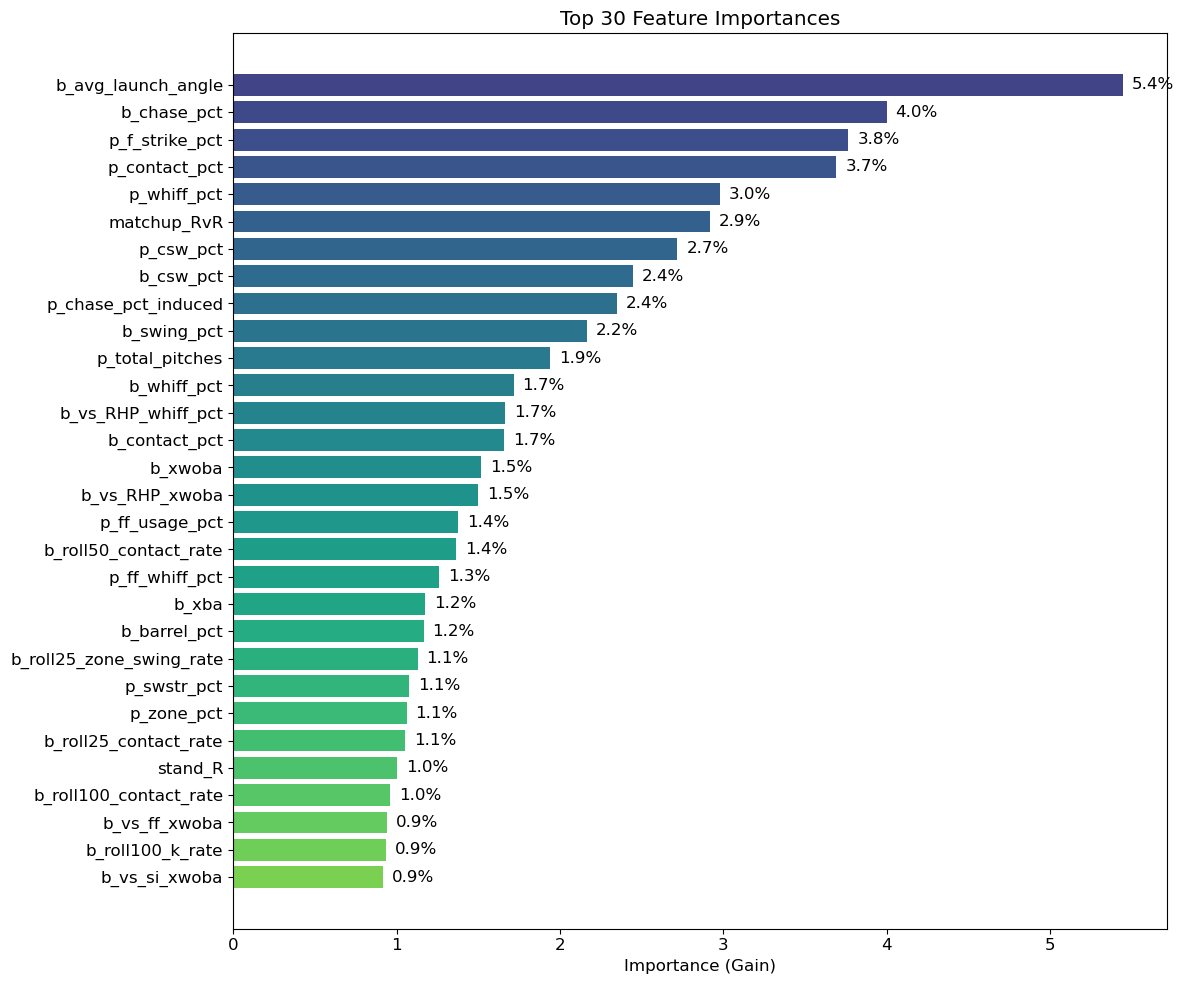

In [14]:
# Feature importance plot
fig = trainer.plot_feature_importance(top_n=30, figsize=(12, 10))
plt.show()

In [15]:
# Feature importance by category
def categorize_feature(name):
    if name.startswith('p_roll'):
        return 'Pitcher Rolling'
    elif name.startswith('b_roll'):
        return 'Batter Rolling'
    elif name.startswith('p_') and 'usage' in name:
        return 'Pitch Usage'
    elif name.startswith('p_') and ('velo' in name or 'spin' in name or 'mov' in name):
        return 'Pitch Characteristics'
    elif name.startswith('p_') and 'whiff' in name:
        return 'Pitcher Whiff'
    elif name.startswith('b_vs_'):
        return 'Batter vs Pitch Type'
    elif name.startswith('b_'):
        return 'Batter Profile'
    elif 'matchup' in name or 'hand' in name or 'stand' in name or 'throws' in name:
        return 'Handedness'
    else:
        return 'Other'

importance_df['category'] = importance_df['feature'].apply(categorize_feature)

category_importance = importance_df.groupby('category')['importance_pct'].sum().sort_values(ascending=False)
print("\nFeature Importance by Category:")
for cat, pct in category_importance.items():
    print(f"  {cat:25s}: {pct:.1f}%")


Feature Importance by Category:
  Batter Profile           : 28.5%
  Other                    : 16.6%
  Batter vs Pitch Type     : 16.0%
  Batter Rolling           : 13.0%
  Pitcher Rolling          : 8.5%
  Handedness               : 5.7%
  Pitcher Whiff            : 4.8%
  Pitch Characteristics    : 3.8%
  Pitch Usage              : 2.9%


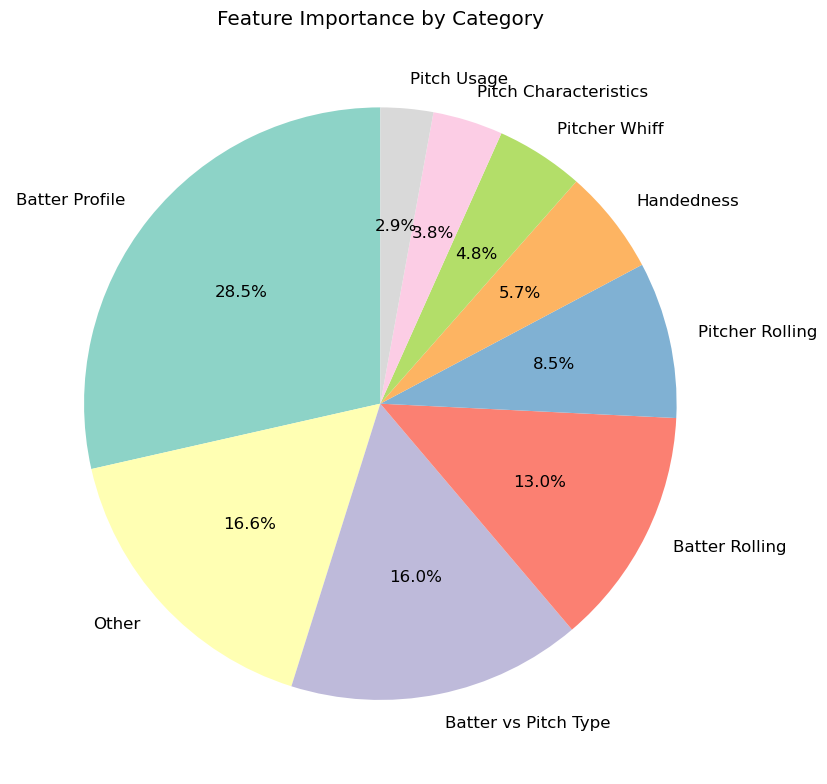

: 

In [ ]:
# Category importance pie chart
fig, ax = plt.subplots(figsize=(10, 8))
category_importance.plot.pie(
    ax=ax,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,
)
ax.set_ylabel('')
ax.set_title('Feature Importance by Category')
plt.tight_layout()
plt.show()

## 5. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides interpretable explanations for individual predictions.

In [ ]:
# Initialize SHAP explainer with background data
trainer.init_shap_explainer(X_train, max_samples=1000)

Initializing SHAP explainer with 1000 background samples...


### 5.1 Individual Prediction Explanations

Waterfall plots show how each feature contributes to a specific prediction.


Sample 80474
True outcome: 1B
Predicted: OUT (P=0.446)
All probabilities:
  1B: 0.119
  2B: 0.052
  3B: 0.002
  BB: 0.093
  HR: 0.038
  K: 0.250
  OUT: 0.446


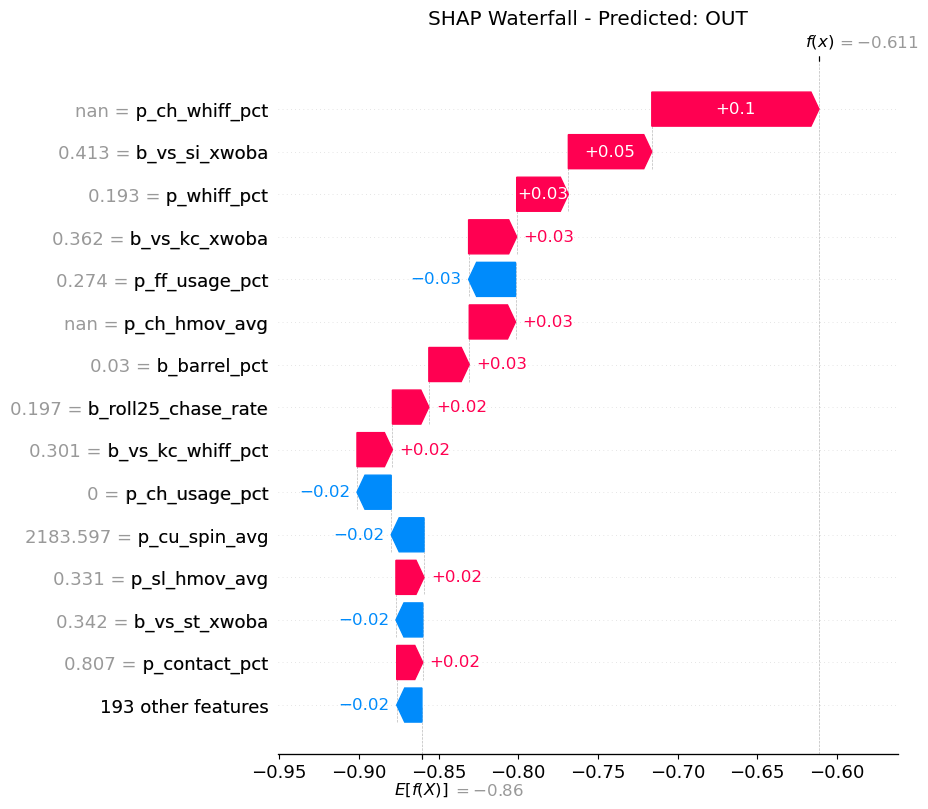


Sample 30860
True outcome: BB
Predicted: OUT (P=0.429)
All probabilities:
  1B: 0.132
  2B: 0.027
  3B: 0.005
  BB: 0.102
  HR: 0.013
  K: 0.292
  OUT: 0.429


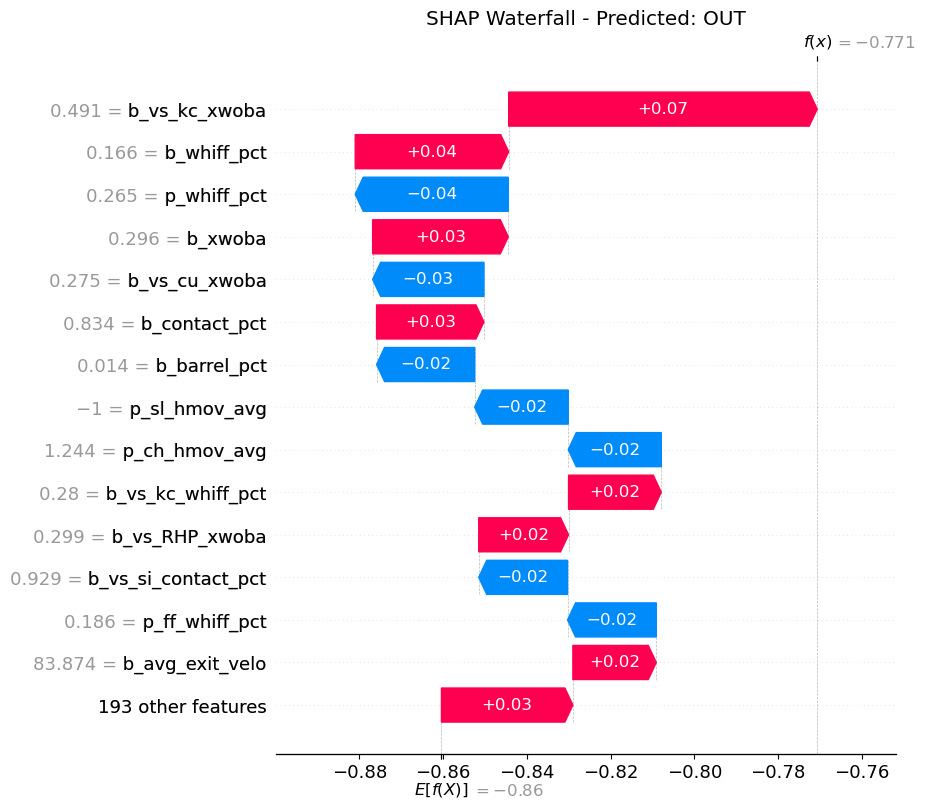


Sample 69892
True outcome: K
Predicted: K (P=0.392)
All probabilities:
  1B: 0.086
  2B: 0.042
  3B: 0.003
  BB: 0.068
  HR: 0.020
  K: 0.392
  OUT: 0.388


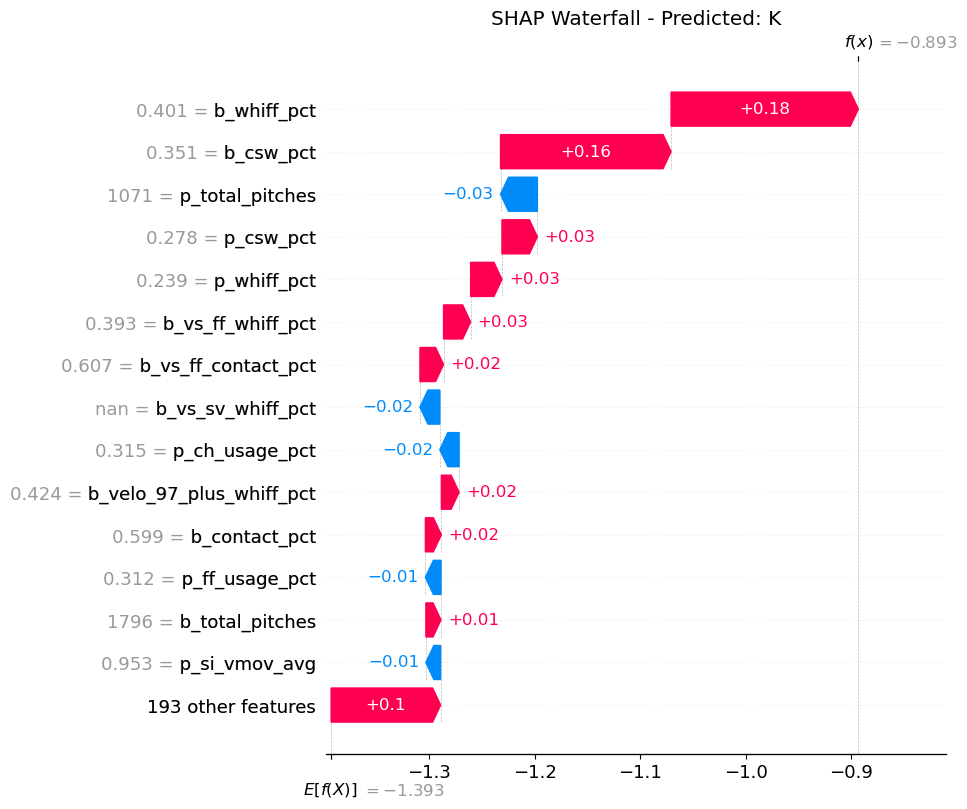


Sample 85292
True outcome: 2B
Predicted: OUT (P=0.514)
All probabilities:
  1B: 0.149
  2B: 0.041
  3B: 0.005
  BB: 0.064
  HR: 0.009
  K: 0.217
  OUT: 0.514


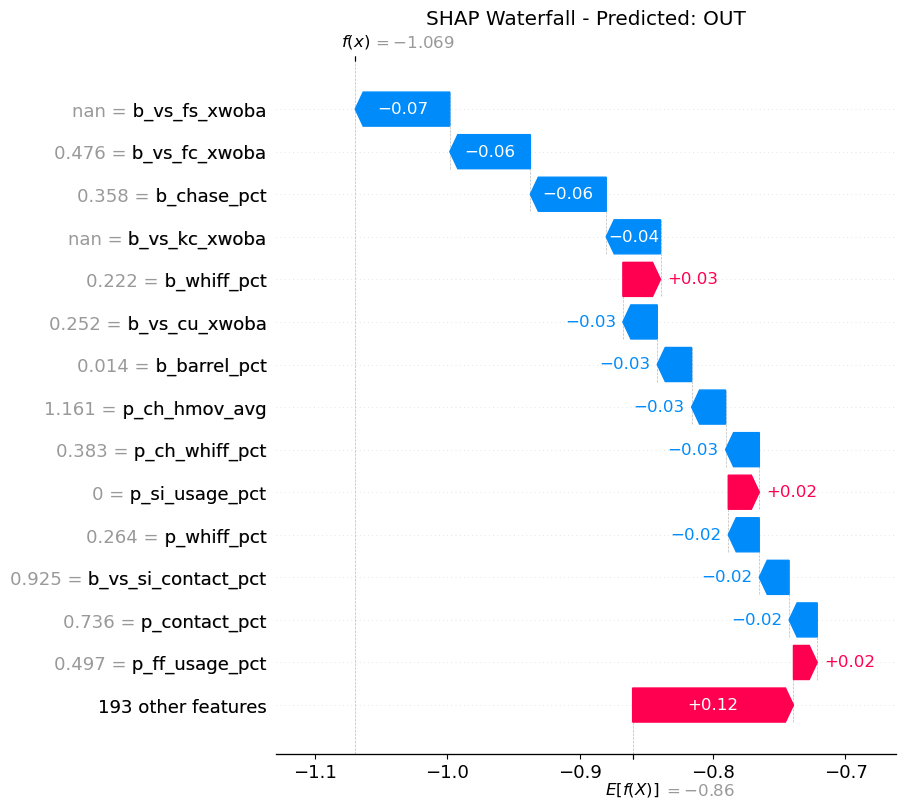


Sample 77706
True outcome: 1B
Predicted: OUT (P=0.428)
All probabilities:
  1B: 0.146
  2B: 0.037
  3B: 0.004
  BB: 0.112
  HR: 0.016
  K: 0.258
  OUT: 0.428


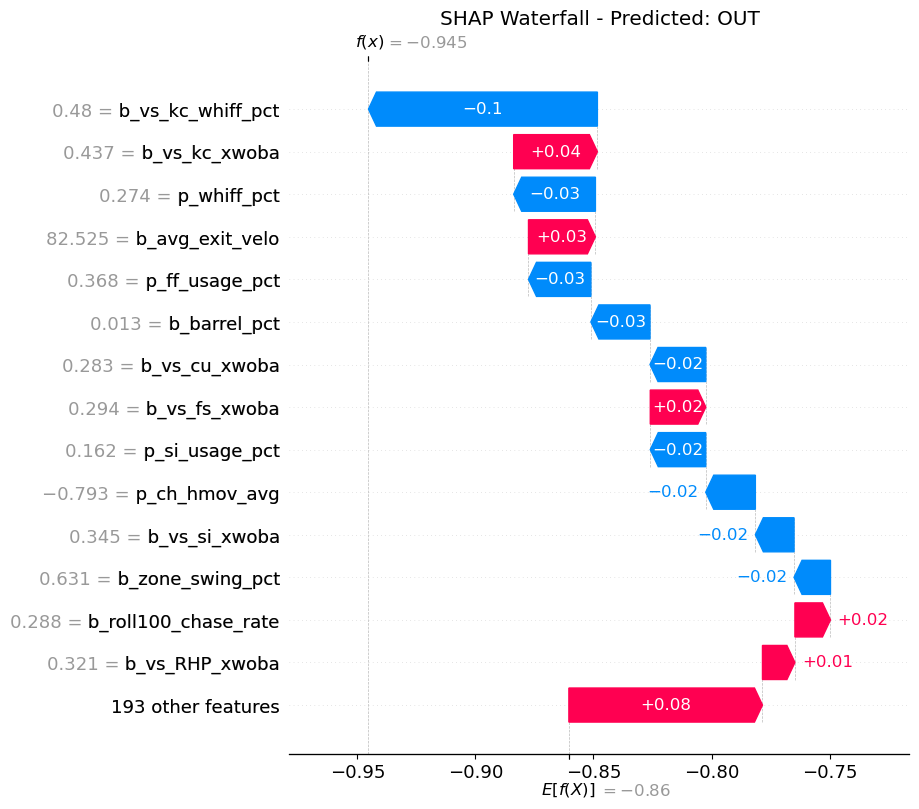

In [ ]:
# Get some example predictions from test set
n_examples = 5
example_indices = np.random.choice(len(X_test), n_examples, replace=False)

for idx in example_indices:
    X_sample = X_test.iloc[[idx]]
    y_true = y_test[idx]
    y_pred = trainer.predict(X_sample)[0]
    y_proba = trainer.predict_proba(X_sample)[0]
    
    print(f"\n{'='*60}")
    print(f"Sample {idx}")
    print(f"True outcome: {outcome_classes[y_true]}")
    print(f"Predicted: {outcome_classes[y_pred]} (P={y_proba[y_pred]:.3f})")
    print(f"All probabilities:")
    for i, cls in enumerate(outcome_classes):
        print(f"  {cls}: {y_proba[i]:.3f}")
    
    # SHAP waterfall for predicted class
    shap_vals, fig = trainer.explain_prediction(
        X_sample,
        class_idx=y_pred,
        plot_type='waterfall',
    )
    plt.show()

### 5.2 Global SHAP Summary

Summary plots show overall feature importance and impact direction.

In [ ]:
# Compute SHAP values for a subset of test data
shap_sample = X_test.sample(min(500, len(X_test)), random_state=42)
print(f"Computing SHAP values for {len(shap_sample)} samples...")
shap_values = trainer.shap_explainer(shap_sample)

Computing SHAP values for 500 samples...


 99%|===================| 3476/3500 [17:51<00:07]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was -1.140415, while the model output was -1.108085. If this difference is acceptable you can set check_additivity=False to disable this check.

In [ ]:
# SHAP summary for Strikeouts (K)
K_idx = outcome_classes.index('K')
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values[:, :, K_idx],
    shap_sample,
    max_display=20,
    show=False,
)
plt.title('SHAP Summary - Strikeout (K) Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# SHAP summary for Walks (BB)
BB_idx = outcome_classes.index('BB')
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values[:, :, BB_idx],
    shap_sample,
    max_display=20,
    show=False,
)
plt.title('SHAP Summary - Walk (BB) Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# SHAP summary for Home Runs (HR)
HR_idx = outcome_classes.index('HR')
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values[:, :, HR_idx],
    shap_sample,
    max_display=20,
    show=False,
)
plt.title('SHAP Summary - Home Run (HR) Prediction')
plt.tight_layout()
plt.show()

### 5.3 SHAP Dependence Plots

Show relationship between feature values and SHAP impact.

In [ ]:
# Top features for dependence plots
top_features = importance_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

K_idx = outcome_classes.index('K')

for i, feat in enumerate(top_features):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values[:, :, K_idx].values,
        shap_sample,
        ax=axes[i],
        show=False,
    )
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.suptitle('SHAP Dependence Plots (Strikeout Prediction)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Save Model and Artifacts

In [ ]:
# Save model and artifacts
output_dir = Path('../models')
output_dir.mkdir(parents=True, exist_ok=True)

# Save trainer
trainer.save(output_dir / 'flaml_trainer.pkl')

# Save metrics report
trainer.save_metrics_report(output_dir / 'metrics_report.json')

# Save feature importance
importance_df.to_csv(output_dir / 'feature_importance.csv', index=False)

# Save confusion matrix plot
fig = trainer.plot_confusion_matrix(test_metrics, save_path=str(output_dir / 'confusion_matrix.png'))
plt.close(fig)

# Save feature importance plot
fig = trainer.plot_feature_importance(save_path=str(output_dir / 'feature_importance.png'))
plt.close(fig)

print("\nAll artifacts saved to models/")

Saved trainer to ../models/flaml_trainer.pkl
Saved metrics report to ../models/metrics_report.json
Saved confusion matrix to ../models/confusion_matrix.png
Saved feature importance plot to ../models/feature_importance.png

All artifacts saved to models/


## 7. Model Loading and Inference Example

In [ ]:
# Example: Load trained model and make predictions
loaded_trainer = MatchupModelTrainer.load(output_dir / 'flaml_trainer.pkl')

# Make prediction on a sample
sample = X_test.iloc[:5]
predictions = loaded_trainer.predict(sample)
probabilities = loaded_trainer.predict_proba(sample)

print("Sample predictions:")
for i in range(len(sample)):
    pred_class = outcome_classes[predictions[i]]
    proba = probabilities[i]
    print(f"  Sample {i}: Predicted {pred_class}, probabilities: ", end='')
    print({cls: f"{p:.3f}" for cls, p in zip(outcome_classes, proba)})

Sample predictions:
  Sample 0: Predicted OUT, probabilities: {np.str_('1B'): '0.082', np.str_('2B'): '0.036', np.str_('3B'): '0.001', np.str_('BB'): '0.118', np.str_('HR'): '0.033', np.str_('K'): '0.356', np.str_('OUT'): '0.374'}
  Sample 1: Predicted OUT, probabilities: {np.str_('1B'): '0.194', np.str_('2B'): '0.061', np.str_('3B'): '0.007', np.str_('BB'): '0.124', np.str_('HR'): '0.017', np.str_('K'): '0.085', np.str_('OUT'): '0.512'}
  Sample 2: Predicted OUT, probabilities: {np.str_('1B'): '0.190', np.str_('2B'): '0.054', np.str_('3B'): '0.002', np.str_('BB'): '0.089', np.str_('HR'): '0.048', np.str_('K'): '0.133', np.str_('OUT'): '0.484'}
  Sample 3: Predicted OUT, probabilities: {np.str_('1B'): '0.172', np.str_('2B'): '0.038', np.str_('3B'): '0.010', np.str_('BB'): '0.117', np.str_('HR'): '0.031', np.str_('K'): '0.211', np.str_('OUT'): '0.422'}
  Sample 4: Predicted OUT, probabilities: {np.str_('1B'): '0.159', np.str_('2B'): '0.052', np.str_('3B'): '0.004', np.str_('BB'): '0.157

## Summary

The FLAML AutoML model has been trained and evaluated. Key outputs:

1. **Model**: `models/flaml_trainer.pkl`
2. **Metrics**: `models/metrics_report.json`
3. **Feature Importance**: `models/feature_importance.csv`
4. **Plots**: `models/confusion_matrix.png`, `models/feature_importance.png`

The model can be loaded with `MatchupModelTrainer.load()` for inference.